# Word2Vec & Glove
- Word2vec is a  nural network  model that learns word representations


In [3]:
from gensim.models import Word2Vec

sentences = [
    ["i", "love", "cats"],
    ["i", "love", "dogs"],
    ["cats", "are", "cute"],
    ["dogs", "are", "loyal"]
]
model = Word2Vec(sentences , vector_size = 100, window = 5 , min_count = 1, sg = 0)
print("get vecotrs for words")
print(model.wv['cats'])

print("find similar words to cats")
print(model.wv.most_similar('cats'))

get vecotrs for words
[ 9.4563962e-05  3.0773198e-03 -6.8126451e-03 -1.3754654e-03
  7.6685809e-03  7.3464094e-03 -3.6732971e-03  2.6427018e-03
 -8.3171297e-03  6.2054861e-03 -4.6373224e-03 -3.1641065e-03
  9.3113566e-03  8.7338570e-04  7.4907029e-03 -6.0740625e-03
  5.1605068e-03  9.9228229e-03 -8.4573915e-03 -5.1356913e-03
 -7.0648370e-03 -4.8626517e-03 -3.7785638e-03 -8.5361991e-03
  7.9556061e-03 -4.8439382e-03  8.4236134e-03  5.2625705e-03
 -6.5500261e-03  3.9578713e-03  5.4701497e-03 -7.4265362e-03
 -7.4057197e-03 -2.4752307e-03 -8.6257253e-03 -1.5815723e-03
 -4.0343284e-04  3.2996845e-03  1.4418805e-03 -8.8142155e-04
 -5.5940580e-03  1.7303658e-03 -8.9737179e-04  6.7936908e-03
  3.9735902e-03  4.5294715e-03  1.4343059e-03 -2.6998555e-03
 -4.3668128e-03 -1.0320747e-03  1.4370275e-03 -2.6460087e-03
 -7.0737829e-03 -7.8053069e-03 -9.1217868e-03 -5.9351693e-03
 -1.8474245e-03 -4.3238713e-03 -6.4606704e-03 -3.7173224e-03
  4.2891586e-03 -3.7390434e-03  8.3781751e-03  1.5339935e-03
 -

- vector_size: embedding dimension (100–300 common)
- window: context window size
- min_count: ignore rare words
- sg: 0 (CBOW), 1 (Skip-Gram)
- epochs: number of training iterations

In [8]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize
corpus = [
    "Ethiopia is known for coffee and culture",
    "Addis Ababa is the capital of Ethiopia",
    "Coffee is a major export product"
]
sentence_token = [word_tokenize(sentence.lower()) for sentence in corpus]
model = Word2Vec(sentence_token, vector_size=100, window=5, min_count=1, sg=1)
model.save('et.model')
model = Word2Vec.load('et.model')

In [9]:
print("get vectors for words")
print(model.wv['ethiopia'])
print("find similar words to ethiopia")
print(model.wv.most_similar('ethiopia'))

get vectors for words
[ 9.3297342e-05  3.0784465e-03 -6.8130000e-03 -1.3751298e-03
  7.6688686e-03  7.3455418e-03 -3.6738745e-03  2.6427626e-03
 -8.3178841e-03  6.2049692e-03 -4.6377336e-03 -3.1641882e-03
  9.3101533e-03  8.7349123e-04  7.4917306e-03 -6.0731629e-03
  5.1615294e-03  9.9236313e-03 -8.4576532e-03 -5.1364773e-03
 -7.0643341e-03 -4.8630559e-03 -3.7773130e-03 -8.5365605e-03
  7.9565663e-03 -4.8432867e-03  8.4224027e-03  5.2626757e-03
 -6.5501416e-03  3.9588478e-03  5.4715397e-03 -7.4265786e-03
 -7.4051893e-03 -2.4760889e-03 -8.6249541e-03 -1.5817122e-03
 -4.0361503e-04  3.3008971e-03  1.4425312e-03 -8.8102336e-04
 -5.5938121e-03  1.7294829e-03 -8.9779211e-04  6.7942590e-03
  3.9732279e-03  4.5294156e-03  1.4346859e-03 -2.6999677e-03
 -4.3662386e-03 -1.0320354e-03  1.4377144e-03 -2.6466507e-03
 -7.0741293e-03 -7.8048673e-03 -9.1221472e-03 -5.9345346e-03
 -1.8465479e-03 -4.3235398e-03 -6.4609838e-03 -3.7163482e-03
  4.2890138e-03 -3.7383446e-03  8.3783381e-03  1.5342247e-03
 -

## Train worwd2vec on Worldwide Coffee Habits Dataset ☕


load and explore datasets

In [12]:
import pandas as pd
df = pd.read_csv('C:/Users/ajmel/Desktop/NLP-LLM-Learning-Journey/Week 1  — NLP Foundations + Embeddings/datasets/worldwide_coffee_habits.csv')
df.head()

,Country,Year,Coffee Consumption (kg per capita per year),Average Coffee Price (USD per kg),Type of Coffee Consumed,Population (millions)
0,Country_39,2023,9.253939,6.467453,Americano,65.929478
1,Country_29,2011,9.981203,4.346744,Mocha,82.456680
2,Country_15,2020,3.312916,8.767496,Latte,110.938862
3,Country_43,2005,2.436180,11.748750,Espresso,43.137207
4,Country_8,2019,4.637849,8.999099,Mocha,65.484262


Preprocesses

In [15]:
import re
from nltk.tokenize  import word_tokenize
from nltk.corpus import stopwords
stop_word = set(stopwords.words('english'))

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', str(text).lower())
    tokens = word_tokenize(text)
    return [word for word in tokens if word not in stop_word]
df['tokens'] = df['Type of Coffee Consumed'].apply(clean_text)


Train word2Vec model

In [16]:
from gensim.models import Word2Vec

# Create a list of token lists
corpus = df['tokens'].tolist()

# Train the model
model = Word2Vec(sentences=corpus, vector_size=100, window=5, min_count=1, workers=4)

# Save the model
model.save("coffee_word2vec.model")

Explore the Model

In [17]:
model.wv.most_similar("espresso")
model.wv.similarity("latte", "cappuccino")
model.wv["mocha"]  # Vector representation


array([ 9.4563962e-05,  3.0773198e-03, -6.8126451e-03, -1.3754654e-03,
        7.6685809e-03,  7.3464094e-03, -3.6732971e-03,  2.6427018e-03,
       -8.3171297e-03,  6.2054861e-03, -4.6373224e-03, -3.1641065e-03,
        9.3113566e-03,  8.7338570e-04,  7.4907029e-03, -6.0740625e-03,
        5.1605068e-03,  9.9228229e-03, -8.4573915e-03, -5.1356913e-03,
       -7.0648370e-03, -4.8626517e-03, -3.7785638e-03, -8.5361991e-03,
        7.9556061e-03, -4.8439382e-03,  8.4236134e-03,  5.2625705e-03,
       -6.5500261e-03,  3.9578713e-03,  5.4701497e-03, -7.4265362e-03,
       -7.4057197e-03, -2.4752307e-03, -8.6257253e-03, -1.5815723e-03,
       -4.0343284e-04,  3.2996845e-03,  1.4418805e-03, -8.8142155e-04,
       -5.5940580e-03,  1.7303658e-03, -8.9737179e-04,  6.7936908e-03,
        3.9735902e-03,  4.5294715e-03,  1.4343059e-03, -2.6998555e-03,
       -4.3668128e-03, -1.0320747e-03,  1.4370275e-03, -2.6460087e-03,
       -7.0737829e-03, -7.8053069e-03, -9.1217868e-03, -5.9351693e-03,
      

Visualize Word Embeddings (Optional)

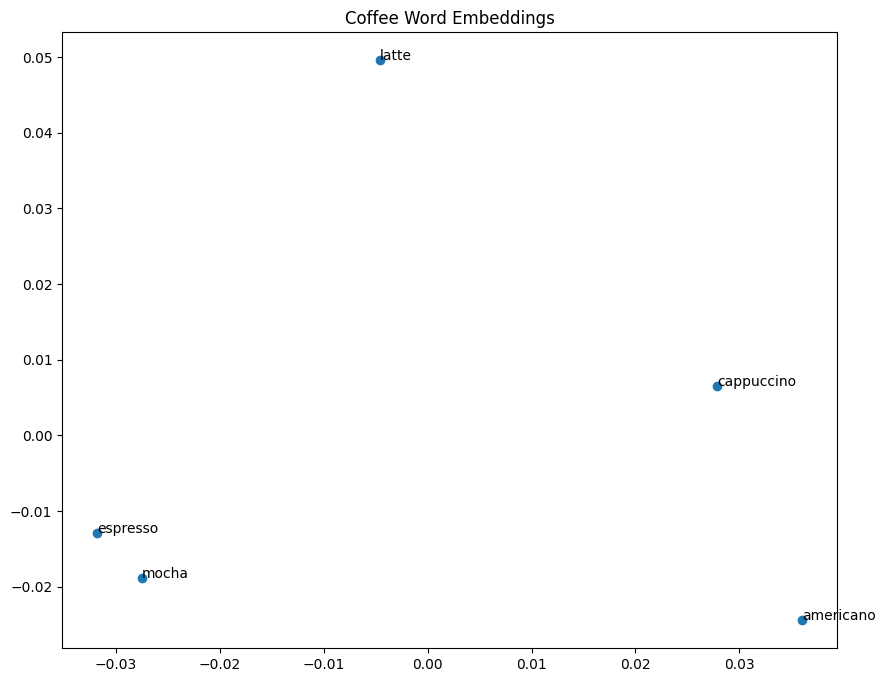

In [18]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

words = list(model.wv.index_to_key)
word_vectors = model.wv[words]

pca = PCA(n_components=2)
result = pca.fit_transform(word_vectors)

plt.figure(figsize=(10, 8))
plt.scatter(result[:, 0], result[:, 1])
for i, word in enumerate(words):
    plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.title("Coffee Word Embeddings")
plt.show()


## Word2Vec Demo
let’s download a pre-trained model and play around with it. We will fetch the Word2Vec model trained on part of the Google News dataset, covering approximately 3 million words and phrases


In [1]:
import gensim.downloader as api
from urllib.error import ContentTooShortError

# Load the pre-trained Word2Vec model with error handling
try:
	model = api.load("word2vec-google-news-300")
except ContentTooShortError as e:
	print("Download was interrupted or incomplete. Please check your internet connection and try again.")
	model = None

[=-------------------------------------------------] 2.4% 40.0/1662.8MB downloadedDownload was interrupted or incomplete. Please check your internet connection and try again.


# Glove